# Mislabeled data detection - RoBERTa-MRPC

This notebook demonstrates how to efficiently compute the influence functions using RRInf, showing its application to **mislabeled data detection** tasks.

- Model: Robert-large (https://arxiv.org/abs/1907.11692; pretrained with publicly available datasets including BOOKCORPUS, WIKIPEDIA, and CC-NEWS)
- Fine-tuning dataset: GLUE-mrpc

References
- https://github.com/huggingface/peft/blob/main/examples/sequence_classification/LoRA.ipynb

In [3]:
import sys
sys.path.append('./src')
from dataloader import create_dataloaders
from lora_model import LORAEngine
from influence import IFEngine


import numpy as np
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## Set up hyperparameters and LoRA models

In [ ]:
from transformers import AutoModel
from transformers import AutoTokenizer
import torch
import os

save_directory = "roberta-large"
task="mrpc"
noise_ratio=0.2
batch_size=32
target_modules=["value"]
device="cuda"
num_epochs=10
lr=3e-4


# Create dataloaders
dataloader_outputs = create_dataloaders(
    model_name_or_path=save_directory,
    task=task,
    noise_ratio=noise_ratio,
    batch_size=batch_size
)

# Unpack dataloader outputs
train_dataloader, eval_dataloader, noise_index, tokenized_datasets, collate_fn = dataloader_outputs


# Instantiate LORAEngine
lora_engine = LORAEngine(
    model_name_or_path=save_directory,
    target_modules=target_modules,
    train_dataloader=train_dataloader,
    eval_dataloader=eval_dataloader,
    device=device,
    num_epochs=num_epochs,
    lr=lr,  # Ensure lr is correctly assigned
    low_rank=8,
    task=task
)

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


Extracting data files:   0%|          | 0/3 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/3668 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/408 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1725 [00:00<?, ? examples/s]

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/3668 [00:00<?, ? examples/s]

Map:   0%|          | 0/408 [00:00<?, ? examples/s]

Map:   0%|          | 0/1725 [00:00<?, ? examples/s]

## fine-tuning a model

In [ ]:
#Build and train the LoRA model
lora_engine.build_LORA_model()
lora_engine.train_LORA_model()

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at ./models/roberta-large and are newly initialized: ['classifier.out_proj.bias', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


trainable params: 2,496,516 || all params: 356,806,660 || trainable%: 0.6996831281120145


100%|██████████| 13/13 [00:06<00:00,  2.03it/s]


Epoch 1: {'accuracy': 0.6838235294117647, 'f1': 0.8122270742358079}


100%|██████████| 13/13 [00:06<00:00,  2.10it/s]


...

Epoch 8: {'accuracy': 0.7990196078431373, 'f1': 0.8660130718954249}


100%|██████████| 13/13 [00:06<00:00,  2.11it/s]


Epoch 9: {'accuracy': 0.7892156862745098, 'f1': 0.8491228070175438}


100%|██████████| 13/13 [00:06<00:00,  2.10it/s]

Epoch 10: {'accuracy': 0.7990196078431373, 'f1': 0.8581314878892734}


## Compute the gradient
 - Influence function uses the first-order gradient of a loss function. Here we compute gradients using `compute_gradient`
 - `tr_grad_dict` has a nested structure of two Python dictionaries. The outer dictionary has `{an index of the training data: a dictionary of gradients}` and the inner dictionary has `{layer name: gradients}`. The `val_grad_dict` has the same structure but for the validationd data points.

In [ ]:
tr_grad_dict, val_grad_dict = lora_engine.compute_gradient(tokenized_datasets, collate_fn)

100%|██████████| 408/408 [00:30<00:00, 13.21it/s]


## Compute the influence function
 - We compute the baseline methods using `compute_IF_baselines(compute_accurate=False)` including `Hessian-free`, `LiSSA` and `DataInf`.
 - We compute RRInf using `compute_IF_RRInf()` with the argument `layer=False` which samples a neuron at each iteration.

In [ ]:
influence_engine = IFEngine()
influence_engine.preprocess_gradients(tr_grad_dict, val_grad_dict, noise_index)
influence_engine.compute_IF_baselines(compute_accurate=False)
influence_engine.compute_IF_RRInf(num_iterations=1000, learning_rate=0.01,layer=False)

Running RRInf for Influence Function: 100%|██████████| 1000/1000 [00:00<00:00, 2380.70it/s]


## Attributes of influence_engine
To compare the runtime, one can use `time_dict` attribute in `influence_engine`.

In [8]:
influence_engine.time_dict

defaultdict(list,
            {'identity': 3.2440409660339355,
             'DataInf': 20.869877576828003,
             'LiSSA': 96.52809762954712,
             'RRInf': 0.49303627014160156})

`IF_dict` includes all the computed influence function values. Here, `identity` indicates the `Hessian-free` influence computation method.

In [9]:
influence_engine.IF_dict.keys()

dict_keys(['identity', 'DataInf', 'LiSSA', 'RRInf'])

## Application to mislabeled data detection task
- We compare the mislabeled data detection ability of different influence computation methods. Given that large influence function values are likely to increase the validation loss, data points with large influence fucntion values are desired to be mislabeled.
- We inspect data points from the largest to lowest influence function values and evaluate the detection rate.

In [10]:
n_train=influence_engine.n_train
true_label=np.zeros(n_train)
true_label[noise_index]=1

method_dict={'identity': 'Hessian-free',
            'DataInf': 'DataInf',
            'LiSSA': 'LiSSA',
            'RRInf':'RRInf'}

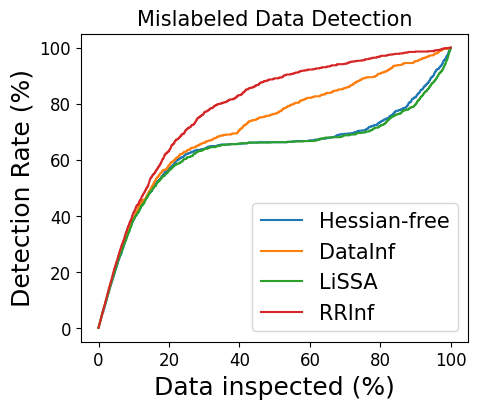

In [11]:
plt.figure(figsize=(5,4))
for method in influence_engine.IF_dict:
    detection_rate_list=[]
    low_quality_to_high_quality=np.argsort(influence_engine.IF_dict[method])[::-1]
    for ind in range(1, len(low_quality_to_high_quality)+1):
        detected_samples = set(low_quality_to_high_quality[:ind]).intersection(noise_index)
        detection_rate = 100*len(detected_samples)/len(noise_index)
        detection_rate_list.append(detection_rate)
    plt.plot(100*np.arange(len(low_quality_to_high_quality))/n_train,
             detection_rate_list,
             label=method_dict[method])
plt.xlabel('Data inspected (%)', fontsize=18)
plt.ylabel('Detection Rate (%)', fontsize=18)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(fontsize=15)
plt.title('Mislabeled Data Detection', fontsize=15)
plt.show()

## AUC

In [13]:
auc_value_identity=roc_auc_score(true_label,influence_engine.IF_dict['identity'])
auc_value_lissa=roc_auc_score(true_label,influence_engine.IF_dict['LiSSA'])
auc_value_datainf=roc_auc_score(true_label,influence_engine.IF_dict['DataInf'])
auc_value_rrinf=roc_auc_score(true_label,influence_engine.IF_dict['RRInf'])


print(f'identity AUC: {auc_value_identity:.3f}')
print(f'LiSSA AUC: {auc_value_lissa:.3f}')
print(f'DataInf AUC: {auc_value_datainf:.3f}')
print(f'RRInf AUC: {auc_value_rrinf:.3f}')

identity AUC: 0.669
LiSSA AUC: 0.661
DataInf AUC: 0.774
RRInf AUC: 0.861
